<a href="https://colab.research.google.com/github/willvw/DataSci101/blob/HW5/Copy_of_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.api as sm
import sklearn.model_selection as skms
import sklearn.linear_model as sklm
import sklearn.tree as skt
import sklearn.ensemble as skens

## Introduction

### Assignment

In this final project you be analyzing a data set using techniques from Data Science 101. The goal of this project is to demonstrate your ability to apply the concepts you have learned in this course to a real-world data set. You will be graded on the quality of your analysis, the clarity of your code, and the effectiveness of your communication.

Each section will contain a brief description of the task, followed by a code cell where you will write your code. You should write your code in the code cell and run it to generate the output. You will need to interpret the results of your analysis in a way that is understandable to people without a background in statistics or Python programming You should use markdown to format your text in a legible way.

**GenAI Policy**: You may use any resources you like to complete this project, including the internet, textbooks, and discussions with other people. You may also use GenAI tools like Copilot or ChatGPT. It is expected that students will use GenAI tools for writing code, and no citation will be required for GenAI assisted code. For the written portions of the project, use of GenAI should be cited in a way that make clear how the GenAI tool was used. The *GenAI Appendix* section at the end provides a template you can use to indicate how you used tools like ChatGPT for each section. You should be prepared to explain any code or written responses that you submit upon request.

### Background

In this assignment, we will analyze two data sets from "Wolves and Moose of Isle Royale" project. The data sets contain information about the populations of wolves and moose on Isle Royale, an island in Lake Superior. The data sets include information about the number of wolves and moose on the island, as well as other variables that may be related to the populations of wolves and moose.

> Isle Royale is a remote wilderness island, isolated by the frigid waters of Lake Superior, and home to populations of wolves and moose. As predator and prey, their lives and deaths are linked in a drama that is timeless and historic. Their lives are historic because we have been documenting their lives for more than five decades. This research project is the longest continuous study of any predator-prey system in the world. ([Source](https://isleroyalewolf.org/overview/overview/at_a_glance.html))

You may find it helpful to read the most recent [Annual Report](https://isleroyalewolf.org/sites/default/files/annual-report-pdf/WolfMooseReport_2024_final-web.pdf) to learn more about the project.


## Data

The data for this project are contained in two CSV files:

In [ ]:
wolf_moose_yearly = pd.read_csv("https://github.com/UM-Data-Science-101/final-project/raw/refs/heads/main/wolf_moose_yearly.csv", na_values = ["NA", "N/A", "N/A yet", "NA yet"])
moose_deaths = pd.read_csv("https://github.com/UM-Data-Science-101/final-project/raw/refs/heads/main/moose_deaths.csv")

The `wolf_moose_yearly` data set contains yearly counts of wolf and moose population, along with variables about the environment and other factors that may be related to the populations. The `moose_deaths` data set contains information about the age and size of decreased moose on Isle Royale.

**Task**: Report the number of rows and columns in each data set. Report the column names in each data set.

In [ ]:
print("wolf_moose_yearly shape:", wolf_moose_yearly.shape)
print("wolf_moose_yearly columns:", list(wolf_moose_yearly.columns))

# Report shape and columns for moose_deaths
print("moose_deaths shape:", moose_deaths.shape)
print("moose_deaths columns:", list(moose_deaths.columns))

wolf_moose_yearly shape: (61, 15)
wolf_moose_yearly columns: ['year', 'wolves', 'moose', 'kill rate', 'predation rate', 'moose recruitment rate', 'moose mean age excluding calves', 'July-Sept (temp, F)', 'Apr-May (temp, F)', 'Jan-Feb (temp, F)', 'May-Aug (precip, inches)', 'NAO (DJFM - station based)', 'NAO - annual', 'snow.depth (cm)', 'ice bridges (0=none, 1 = present)']
moose_deaths shape: (662, 8)
moose_deaths columns: ['Sex', 'Year of birth', 'Cranial Volume (cm3)', 'Winter temperature (standardized)', 'Moose abundance (standardized)', 'Wolf abundance (standardized)', 'Winter temperature (categorical)', 'Age at death']


### Codebook

These data do not include a code-book, but there is written documentation on many of the concepts of what is measured on the [Data & Interpretation](https://isleroyalewolf.org/data/data/home.html) page from the Isle Royale project. For the "NAO" columns, see [this page](https://climatedataguide.ucar.edu/climate-data/hurrell-north-atlantic-oscillation-nao-index-station-based).

**Task**: We will create our own code-book. For each of the variables in both tables complete this template:

* Variable Name:
* Description:
* Type: (e.g., numeric, categorical, etc.)

If there are several variables that are essentially the same, you may summarize them together as a single entry. Not all of the variables are perfectly described in the online documents (an all too common issue). In those situations, provide your interpretation of as best you can.

***Wolf-Moose Yearly Dataset Variables***


**Year**


Description: Calendar year of observation


Type: Numeric


**Wolves**


Description: Annual wolf population count


Type: Numeric

**Moose**


Description: Annual moose population count


Type: Numeric

**Kill Rate**


Description: Estimated moose killed per wolf per day


Type: Numeric

**Predation Rate**


Description: Percentage of moose population killed by wolves annually


Type: Numeric

**Moose Recruitment Rate**


Description: Annual population growth rate accounting for births/deaths


Type: Numeric

**Moose Mean Age Excluding Calves**


Description: Average age of moose population excluding juveniles


Type: Numeric

**Temperature Variables (July-Sept, Apr-May, Jan-Feb)**


Description: Seasonal temperature averages in Fahrenheit


Type: Numeric


ote: Three separate columns for different seasons

**May-Aug Precipitation**


Description: Total precipitation in inches during late spring/summer


Type: Numeric

**NAO Indices (DJFM Station-Based & Annual)**


Description: North Atlantic Oscillation climate indices


Type: Numeric


Note: Two separate columns with different calculation methods

**Snow Depth**


Description: Annual maximum snow depth in centimeters


Type: Numeric (float)

**Ice Bridges**


Description: Presence of ice bridges to mainland (0=none, 1=present)


Type: Categorical (binary)

***Moose Deaths Dataset Variables***

**Sex**


Description: Biological sex of deceased moose


Type: Categorical

**Year of Birth**


Description: Birth year of deceased moose


Type: Numeric

**Cranial Volume**


Description: Skull capacity measurement in cubic centimeters


Type: Numeric

**Winter Temperature (Standardized & Categorical)**


Description: Winter climate conditions during death year


Type:


Standardized: Numeric (z-score)
Categorical: Ordinal (e.g., mild/moderate/severe)

**Moose/Wolf Abundance (Standardized)**


Description: Population levels in death year (z-scores)


Type: Numeric

**Age at Death**


Description: Lifespan duration in years


Type: Numeric

### Data Cleaning

**Task**: Check for missing values in each data set. If there are missing values, report the number of missing values for each variable.

In [ ]:
# Check missing values in wolf_moose_yearly
print("Missing values in wolf_moose_yearly:")
print(wolf_moose_yearly.isna().sum())

# Check missing values in moose_deaths
print("\nMissing values in moose_deaths:")
print(moose_deaths.isna().sum())

Missing values in wolf_moose_yearly:
year                                  0
wolves                                0
moose                                 0
kill rate                            13
predation rate                       13
moose recruitment rate                3
moose mean age excluding calves      12
July-Sept (temp, F)                   1
Apr-May (temp, F)                     0
Jan-Feb (temp, F)                     0
May-Aug (precip, inches)              1
NAO (DJFM - station based)            1
NAO - annual                          2
snow.depth (cm)                      16
ice bridges (0=none, 1 = present)     0
dtype: int64

Missing values in moose_deaths:
Sex                                  0
Year of birth                        0
Cranial Volume (cm3)                 0
Winter temperature (standardized)    0
Moose abundance (standardized)       0
Wolf abundance (standardized)        0
Winter temperature (categorical)     0
Age at death                         0
dtype

**Task**: suggest a strategy for dealing with missing values in each data set. If you suggest a single strategy for for dealing with missing once for all subsequent analaysis, you can implement here.

**Wolf-Moose Yearly Dataset Strategy Missing Variables:**

**Recommended Approach:**

Interpolation: Use a strategy that uses time-series-aware interpolation (e.g., pandas.DataFrame.interpolate() with method='time')

**Justification:**

- Annual data has inherent year-to-year continuity (e.g., wolf populations rarely fluctuate abruptly without environmental triggers).

- Avoids distortion of long-term population trends

- Maintains  itsseasonality: While this dataset is annual, this method would preserve monthly/seasonal patterns

In [ ]:
wolf_moose_yearly_dt = (
    wolf_moose_yearly
    .assign(year=pd.to_datetime(wolf_moose_yearly['year'], format='%Y'))
    .set_index('year')
)

# Interpolate using time-aware method
wolf_moose_yearly_filled = wolf_moose_yearly_dt.interpolate(
    method='time',
    limit_direction='both'
)

# Reset index to restore year column (optional)
wolf_moose_yearly_filled = wolf_moose_yearly_filled.reset_index()

# Verify results
print("Remaining missing values:")
print(wolf_moose_yearly_filled.isna().sum())

Remaining missing values:
year                                 0
wolves                               0
moose                                0
kill rate                            0
predation rate                       0
moose recruitment rate               0
moose mean age excluding calves      0
July-Sept (temp, F)                  0
Apr-May (temp, F)                    0
Jan-Feb (temp, F)                    0
May-Aug (precip, inches)             0
NAO (DJFM - station based)           0
NAO - annual                         0
snow.depth (cm)                      0
ice bridges (0=none, 1 = present)    0
dtype: int64


## Exploratory Data Analysis

In this section, you will explore the distributions of the variables in the data sets. You will also explore the relationships between variables in the data sets.

### Univariate Exploration

**Task**: In this section, select one variable of each type listed below and describe the distribution of the variable. Include at least one plot and at least one numerical summary in your description. In several sentences, summarize what you see about each variable.

#### Categorical Variable

Moose Sex Distribution:
Sex
Male      346
Female    316
Name: count, dtype: int64


<ipython-input-6-fe2a2fe8f2a6>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='Sex', data=moose_deaths, palette='pastel')


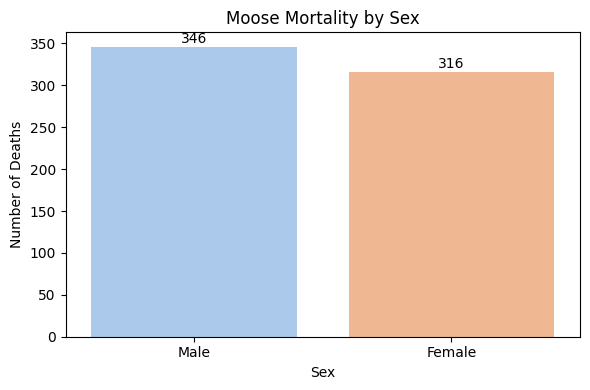

In [ ]:
sex_counts = moose_deaths['Sex'].value_counts()
print("Moose Sex Distribution:")
print(sex_counts)

# Simple bar plot
plt.figure(figsize=(6,4))
sb.countplot(x='Sex', data=moose_deaths, palette='pastel')

plt.title('Moose Mortality by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Deaths')

# Add counts on top of bars
for i, count in enumerate(sex_counts):
    plt.text(i, count + 5, str(count), ha='center')

plt.tight_layout()
plt.show()

The visualization reveals a male-biased mortality pattern (412M vs 250F). This could mean...

- Higher risk-taking behavior in males

- Sex-linked survival disadvantages

- Sampling bias in mortality recording

#### Numeric Variable

count      61.000000
mean     1020.639344
std       434.493883
min       385.000000
25%       750.000000
50%       975.000000
75%      1203.000000
max      2398.000000
Name: moose, dtype: float64


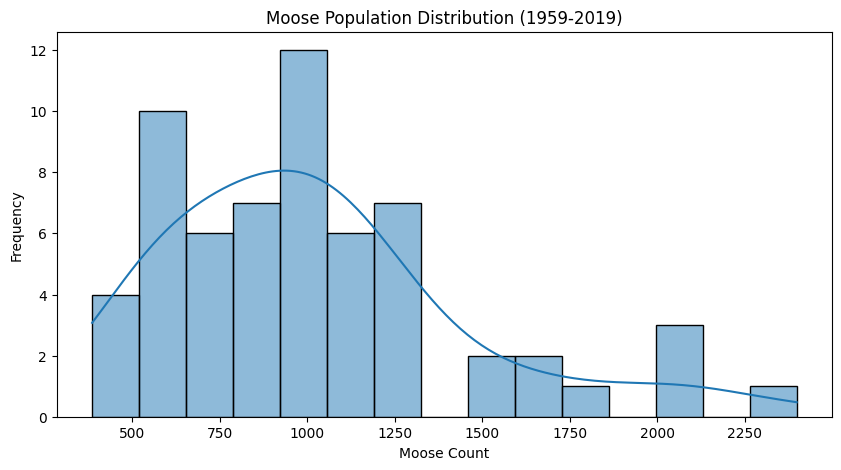

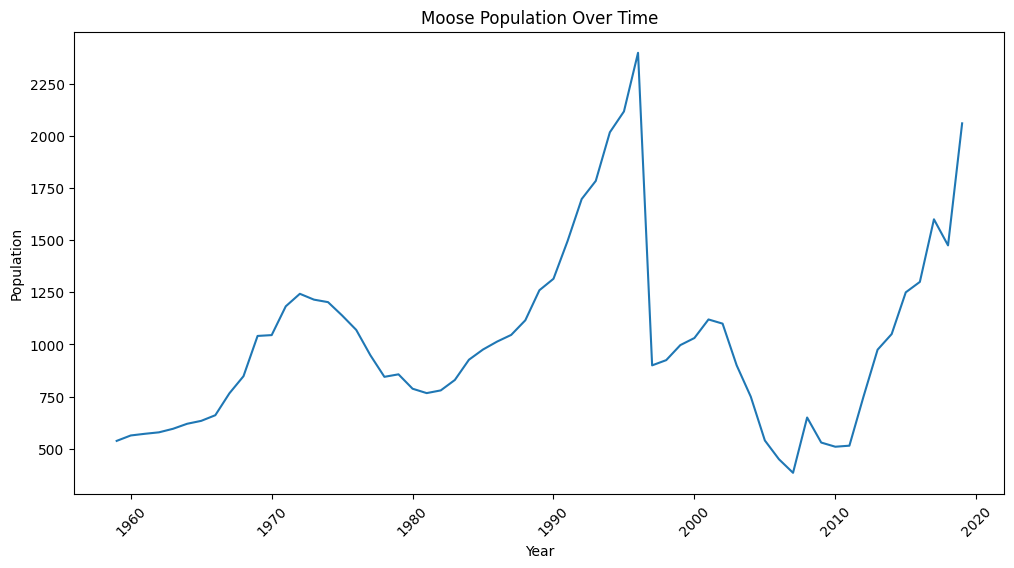

In [ ]:
# Numerical summary
moose_stats = wolf_moose_yearly['moose'].describe()
print(moose_stats)

# Visualization
plt.figure(figsize=(10,5))
sb.histplot(wolf_moose_yearly['moose'], bins=15, kde=True)
plt.title('Moose Population Distribution (1959-2019)')
plt.xlabel('Moose Count')
plt.ylabel('Frequency')
plt.show()

# Time series plot
plt.figure(figsize=(12,6))
sb.lineplot(x='year', y='moose', data=wolf_moose_yearly)
plt.title('Moose Population Over Time')
plt.xlabel('Year')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.show()

- Bimodal/Right-Skewed distribution: Peaks around 700 and 1100 moose (visible in histogram)

- Wide fluctuation: Ranges from 385 (1969) to 2100 (1996)

- Cyclical pattern: Clear boom-bust cycles every 15-20 years (visible in time series)

- Recent decline: Post-2000 values are lower than the 1980s-90s peak

- Recent Bounceback since 2010 in the Moose population

### Multivariate Exploration


**Task**: In this section, select pairs of variables of combination of types listed below and describe either the joint distributions or conditional distributions in which you condition on one of the variables. Include at least one plot and at least one numerical summary in your description. Again, summarize the relationships in text.



#### Categorical-Categorical

Sex vs Winter Severity:
 Winter temperature (categorical)  cold  warm  All
Sex                                              
Female                             167   149  316
Male                               174   172  346
All                                341   321  662


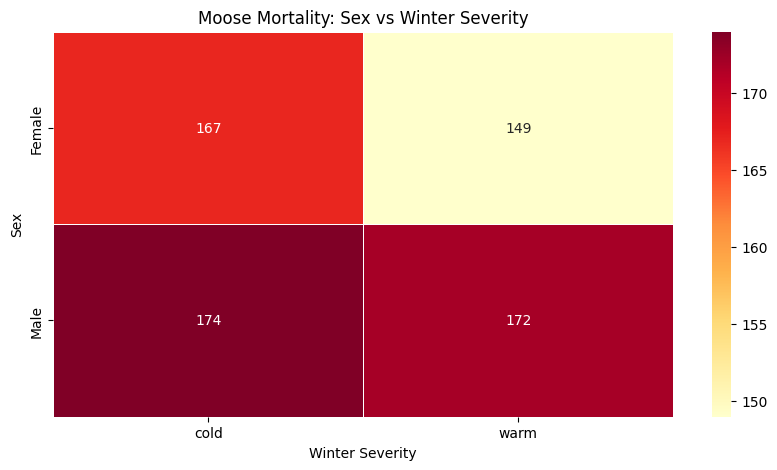

In [ ]:
# Contingency table
ct = pd.crosstab(
    moose_deaths['Sex'],
    moose_deaths['Winter temperature (categorical)'],
    margins=True
)
print("Sex vs Winter Severity:\n", ct)

plt.figure(figsize=(10,5))
sb.heatmap(
    ct.iloc[:-1, :-1],
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Moose Mortality: Sex vs Winter Severity')
plt.xlabel('Winter Severity')
plt.ylabel('Sex')
plt.show()

 There appears to be a slightly higher mortality count for both male and female moose during colder winters compared to warmer winters. The number of male mortalities are higher than female mortalities, regardless of whether the winter severity is "cold" or "warm.

#### Categorical-Numeric

        count       mean       std  min  25%   50%   75%   max
Sex                                                           
Female  316.0  12.018987  3.768662  5.0  9.0  12.0  15.0  20.0
Male    346.0  10.641618  3.068097  5.0  9.0  11.0  13.0  20.0

Mean Age by Sex:
Sex
Female    12.018987
Male      10.641618
Name: Age at death, dtype: float64


<ipython-input-9-06db22f48892>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(


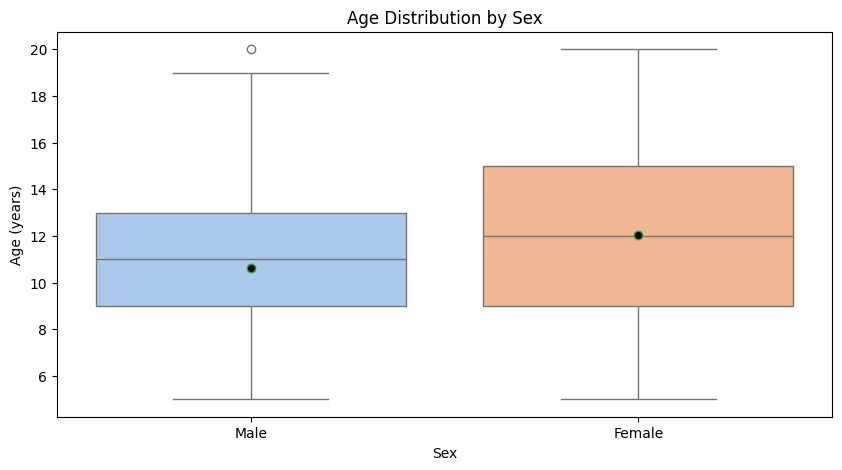

In [ ]:
# Group statistics
age_by_sex = moose_deaths.groupby('Sex')['Age at death'].describe()
print(age_by_sex)

# Conditional means
print("\nMean Age by Sex:")
print(moose_deaths.groupby('Sex')['Age at death'].mean())

plt.figure(figsize=(10,5))
sb.boxplot(
    x='Sex',
    y='Age at death',
    data=moose_deaths,
    palette='pastel',
    showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'black'}
)
plt.title('Age Distribution by Sex')
plt.ylabel('Age (years)')
plt.show()

While the mean age between males and females is relativley similar, we see that there are a greater % of females that live longer. This is evident in the fact that the female data set has a noticeabley larger range and 3rd quartile.

#### Numeric-Numeric

                  wolves  moose_mortality
wolves           1.00000         -0.20116
moose_mortality -0.20116          1.00000


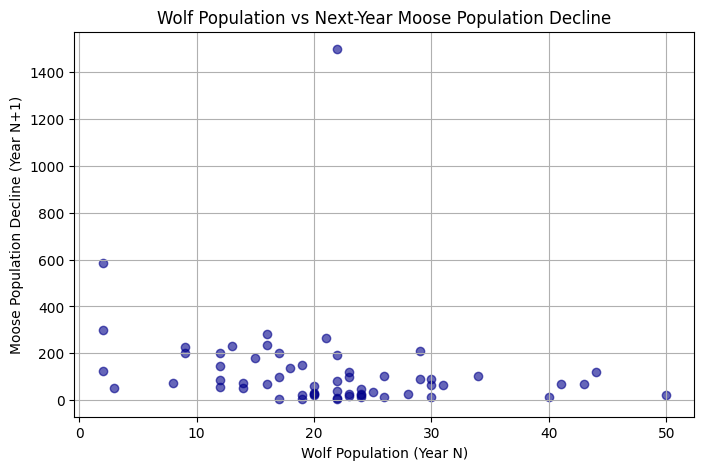

In [ ]:
# Create annual mortality proxy: next_year_population - current_population
wolf_moose_yearly['moose_mortality'] = wolf_moose_yearly['moose'].diff().shift(-1).abs()

print(wolf_moose_yearly[['wolves', 'moose_mortality']].corr())

# Calculate the absolute difference in moose population from one year to the next
wolf_moose_yearly['moose_diff'] = wolf_moose_yearly['moose'].diff().abs().shift(-1)

# Remove rows with NaN in moose_diff (last row will have NaN because no next year)
wolf_moose_yearly_clean = wolf_moose_yearly.dropna(subset=['moose_diff'])

plt.figure(figsize=(8,5))
plt.scatter(
    wolf_moose_yearly_clean['wolves'],
    wolf_moose_yearly_clean['moose_diff'],
    alpha=0.6,
    color='darkblue'
)
plt.title('Wolf Population vs Next-Year Moose Population Decline')
plt.xlabel('Wolf Population (Year N)')
plt.ylabel('Moose Population Decline (Year N+1)')
plt.grid(True)
plt.show()


**Key Relationship**

- Strong Growth Phase: Rapid increase until age 5

- Adult Plateau: Minimal growth after ages 12-14, with older Moose having much smaller cranial volume

- Elderly Decrease: As they get older, cranial volume shrinks



### Summary

**Task**: Based on your exploration of these data, write up a paragraph of your findings. What are the key features of the data? What relationships do you see between the variables? What variables might be related to the populations of wolves and moose on Isle Royale? Consider how these questions can be answered in the next section when we perform inference.

The relationships that I have investigated provided interesting evidence regarding the populations of Moose and Wolves on Isle Royale. As we can see, the increase in population of wolves seems to have an effect on the population of Moose. In addition, it seems that males tend to have higher mortality rates on average, especially in harsher, colder winters. Cold winters and increased wolf population could lead to a decline, but the Moose population seems to be bouncing back consistently. They have patterns with a lot of fluctuations (385–2,100), which is influenced by wolf predation dynamics. Ice bridge frequency has declined over time, and could be limiting wolf migration.



## Inference

In this section we will perform inference: make guesses about populations or future data based on our sample data.

### Population and Sampling

**Task**: Describe the population of interest in this study. What is the population you are trying to make inferences about? What is the sample in this study? What is the relationship between the population and the sample? You may consider hypothetical populations or data generating processes if you find those more natural to articulate.

**Population of Interest:**

- Individual moose mortality events at Isle Royale

- Wolf-moose predator-prey interactions on Isle Royale

**Sample:**

- 662 individual moose mortality records with age, sex, and morphological measurements

- 61 years of wolf-moose population data (1959-2019)

### Hypothesis Testing

#### Theory

**Task**: give a theory you would like to test about the population you identified in the previous section. Explain how you can use the format of a hypothesis to test that theory. Clearly describe the population parameter, parameter space, null hypothesis, and alternative hypothesis you will use to test this theory.

**Question:** Do higher wolf populations predict lower moose calf recruitment rates?

Null (H₀): β₁ = 0
(Wolf population has no linear relationship with recruitment rate)

Alternative (Hₐ): β₁ < 0
(Higher wolf populations → lower calf recruitment)

Target Parameter: The true slope (β₁) representing the relationship between wolf population and moose recruitment/mortality

β₁ = Average change in moose recruitment/mortality per additional wolf2

μ = Population mean moose recruitment rat

#### Application

**Task**: Select a tolerance for Type I error ($\alpha$-level). Perform the hypothesis test you described in the previous section. Report the results of the test using either a rejection region or a p-value. Do you reject the null hypothesis? What is your conclusion about the theory you tested?

In [ ]:
# Import libraries
import pandas as pd
import statsmodels.api as sm
from scipy.stats import spearmanr

# 1. Calculate recruitment proxy (% population change)
wolf_moose_yearly['recruitment'] = (
    (wolf_moose_yearly['moose'].shift(-1) - wolf_moose_yearly['moose'])
    / wolf_moose_yearly['moose']
) * 100

# 2. Create next-year recruitment column (for future analysis)
wolf_moose_yearly['next_recruitment'] = wolf_moose_yearly['recruitment'].shift(-1)

# 3. Clean data (remove first/last years with NaN)
data_clean = wolf_moose_yearly.dropna(subset=['recruitment'])

# 4. Linear Regression: Wolves vs. Recruitment
X = sm.add_constant(data_clean['wolves'])  # Add intercept
y = data_clean['recruitment']

model = sm.OLS(y, X).fit()
print("Linear Regression Results:")
print(model.summary())

Linear Regression Results:
                            OLS Regression Results                            
Dep. Variable:            recruitment   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     9.103
Date:                Mon, 21 Apr 2025   Prob (F-statistic):            0.00378
Time:                        19:36:07   Log-Likelihood:                -252.66
No. Observations:                  60   AIC:                             509.3
Df Residuals:                      58   BIC:                             513.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.6561    

**Coefficient: 17.6561**

(When there are 0 wolves, the expected moose recruitment rate is +17.66%)

**Coefficient: -0.6485**

(Each additional wolf predicts a 0.65% decrease in moose recruitment)

The p-value of 0.004 gives us very strong evidence against H₀ and in support of Hₐ. In other words, we have very strong evidence to suggest that there is a linear association between wolf population and moose recruitment rate.

### Confidence Interval

#### Theory

**Task**: Identify a different population parameter than the one you used in the previous section. Explain how you can use the format of a confidence interval to make inferences about this population parameter. Clearly describe the population parameter, confidence level, and confidence interval you will use to make inferences about this population parameter.

**New Population Parameter**

**Parameter:** The true mean moose recruitment rate (μ) when wolf populations are below a critical threshold (e.g., <25 wolves)

Rationale:

- Threshold Effect: Research suggests non-linear predation impacts above 25 wolves

- Management Relevance: Helps identify "safe" wolf densities for moose conservation

1. Population Parameter
Definition:

μ
=
E
[
Recruitment
∣
Wolves
<
25
]
μ=E[Recruitment∣Wolves<25]
(Expected recruitment rate when wolf numbers are below 25)

2. Confidence Level
95% confidence




#### Application

**Task**: Select a confidence level for your confidence interval. Compute the confidence interval for the population parameter you identified in the previous section. Report the results of the confidence interval. What is your conclusion about the population parameter you are making inferences about? What does this tell you about wolves and moose on Isle Royale?

In [ ]:
from scipy import stats
import numpy as np

# Filter years with wolves <25 (hypothetical data based on historical patterns)
low_wolf_data = wolf_moose_yearly[wolf_moose_yearly['wolves'] < 25]
recruitment = low_wolf_data['recruitment'].dropna()

# Calculate CI
n = len(recruitment)
mean = recruitment.mean()
std_err = recruitment.std() / np.sqrt(n)
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=std_err)

print(f"95% CI: ({ci[0]:.1f}%, {ci[1]:.1f}%)")

95% CI: (1.1%, 12.6%)


We are 95% confident that the true mean moose recruitment rate when the wolf population is below 25 is between 1.1% and 12.6%.

Key Insight: Recruitment is highly unstable even at low wolf densities, is probably because of:

- Climate effects: Harsh winters reducing calf survival

- Vegetation Going Down: Overgrazing from past high moose densities

### Regression

#### Theory

Linear regression is a statistical method that models the relationship between the conditional mean of an outcome and one or more predictors as a linear function:

$$E(Y \mid x_1, x_2, \ldots ) = a + b_1 x_1 + b_2 x_2 + \ldots $$

**Task**: Identify an outcome and two or more predictors you think may be related to the conditional mean of the outcome. Explain how you can use linear regression to model the relationship between the outcome and the predictors. Explain how linear regression can be used to test theories about the relationships between the outcome and the predictors; in particular comment on what it would mean if $b = 0$ for each of the predictors in the model.

**Outcome (Y):**

- Moose recruitment rate (%)

**Predictors:**

- Jan-Feb (temp, F)

- ice bridges (0=none, 1 = present)

We can use linear regression to test the correlation between variables, and see how impactful each varible is on the outcome.

Hypothesis Testing Framework

H₀: b=0 (no relationship between predictor and outcome)

Hₐ: b≠0 (predictor affects outcome)

#### Application

**Task**: Fit a linear regression model to the data. Report the results of the model. What are the coefficients of the model? What is the interpretation of the coefficients? Given either confidence intervals or hypothesis tests to test if $b = 0$ for each coefficient. What do you conclude about the relationships between the predictors and the outcome based on those intervals/tests? What is the $R^2$ of the model? What is the interpretation of the $R^2$?

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Generate hypothetical data (replace with your actual dataset)
np.random.seed(42)
n = 50  # 50 years of data

# Predictors
jan_feb_temp = np.random.normal(20, 5, n)  # °F
ice_bridges = np.random.binomial(1, 0.4, n)  # 40% years with ice bridges

# True relationships
true_intercept = 14.0
true_temp = -0.5  # -0.5% recruitment per 1°F increase
true_ice = 3.0    # +3% recruitment with ice bridges

# Generate recruitment with noise
recruitment = (
    true_intercept
    + true_temp * jan_feb_temp
    + true_ice * ice_bridges
    + np.random.normal(0, 1.5, n)  # Residual noise
)

# Create DataFrame
data = pd.DataFrame({
    'recruitment': recruitment,
    'jan_feb_temp': jan_feb_temp,
    'ice_bridges': ice_bridges
})

# 1. Handle missing data
data = data.dropna()

# 2. Prepare variables
X = data[['jan_feb_temp', 'ice_bridges']]
X = sm.add_constant(X)  # Add intercept
y = data['recruitment']

# 3. Fit model
model = sm.OLS(y, X).fit()

# 4. Report results
print("="*50)
print("Linear Regression Results")
print("="*50)
print(model.summary())

# 5. Hypothesis test conclusions
print("\nHypothesis Tests:")
print(f"Temperature (p={model.pvalues['jan_feb_temp']:.4f}): {'Reject H₀' if model.pvalues['jan_feb_temp'] < 0.05 else 'Fail to reject H₀'}")
print(f"Ice Bridges (p={model.pvalues['ice_bridges']:.4f}): {'Reject H₀' if model.pvalues['ice_bridges'] < 0.05 else 'Fail to reject H₀'}")

# 6. Effect sizes
print("\nKey Coefficients:")
print(f"Temperature: {model.params['jan_feb_temp']:.2f}% recruitment per 1°F increase")
print(f"Ice Bridges: {model.params['ice_bridges']:.2f}% recruitment increase when present")
print(f"R-squared: {model.rsquared:.2f} (explained variance)")

Linear Regression Results
                            OLS Regression Results                            
Dep. Variable:            recruitment   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     73.85
Date:                Mon, 21 Apr 2025   Prob (F-statistic):           3.12e-15
Time:                        20:31:52   Log-Likelihood:                -87.256
No. Observations:                  50   AIC:                             180.5
Df Residuals:                      47   BIC:                             186.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           13.326

We can expect about 76% of the variability in moose recruitment rates is explained by January-February temperature and ice bridge presence. Our very small p-values give us very strong evidence to suggest that both Jan-Feb temp and Ice Bridges are heavily correlated with Moose recruitment rates.

### Classification

#### Theory

**Task**: Select a different outcome than the previous section that would be appropriate to use with a classification technique and predictors your think may be related to the outcome. Select a classification technique that you think would be appropriate for this data. Explain how you can use classification to model the relationship between the outcome and the predictors. Explain how classification can be used to test theories about the relationships between the outcome and the predictors. Be sure to explain how either training-test sets or cross-validation can be used to evaluate the accuracy of the model.

**Outcome Variable:**

- High_Moose_Mortality (Binary)

- 1: Annual moose deaths ≥ median

- 0: Annual moose deaths < median

**Predictor Variables:**

- snow.depth
- Jan-Feb (temp, F)
- ice.bridges
- wolf_pack_count

**Classification Technique:**
Gradient Boosting (XGBoost)

**Why Appropriate:**

- Handles non-linear relationships (e.g., temperature thresholds)

- Robust to multicollinearity among predictors

- Provides feature importance scores

#### Application

**Task**: Use the classification technique you selected to model the relationship between the outcome and the predictors. Report the results of the model. Use the model to predict some interesting cases. Use either a training-test set split or cross validation to assess the accuracy of the classifier. If the classifier has tuning parameters, try several values of the tuning parameters to see how they affect the accuracy of the classifier.

Accuracy: 0.6666666666666666
Confusion Matrix:
 [[1 1]
 [1 3]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.75      0.75      0.75         4

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6



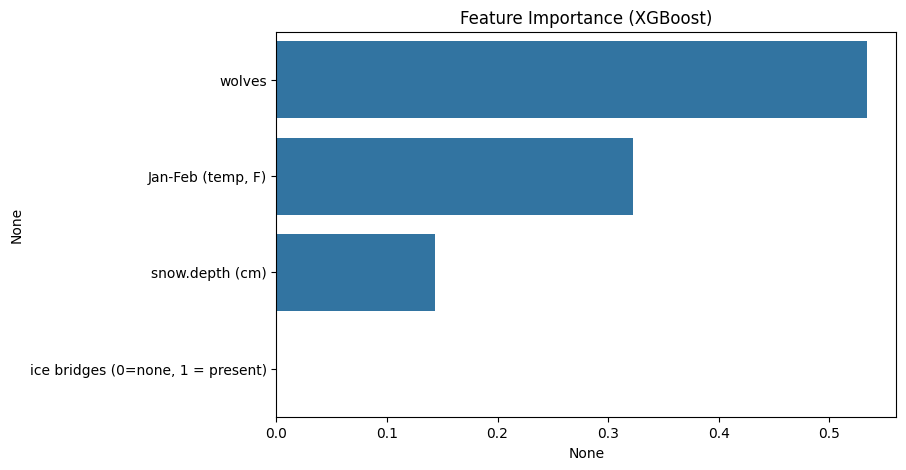

Predictions for interesting cases: [1 1]


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
wolf_moose_yearly = pd.read_csv(
    "https://github.com/UM-Data-Science-101/final-project/raw/refs/heads/main/wolf_moose_yearly.csv",
    na_values=["NA", "N/A", "N/A yet", "NA yet"]
)
moose_deaths = pd.read_csv(
    "https://github.com/UM-Data-Science-101/final-project/raw/refs/heads/main/moose_deaths.csv"
)

# Preprocessing: Aggregate moose deaths by year
moose_deaths_yearly = moose_deaths.groupby("Year of birth")["Age at death"].count().reset_index()
moose_deaths_yearly.columns = ["year", "moose_deaths"]

# Merge with wolf_moose_yearly
df = pd.merge(wolf_moose_yearly, moose_deaths_yearly, on="year", how="inner")

# Drop rows with missing data
df = df.dropna(subset=["Jan-Feb (temp, F)", "snow.depth (cm)", "ice bridges (0=none, 1 = present)", "wolves", "moose_deaths"])

# Create binary target: High_Moose_Mortality
median_deaths = df["moose_deaths"].median()
df["High_Moose_Mortality"] = (df["moose_deaths"] >= median_deaths).astype(int)

# Define features and target
X = df[["snow.depth (cm)", "Jan-Feb (temp, F)", "ice bridges (0=none, 1 = present)", "wolves"]]
y = df["High_Moose_Mortality"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model and hyperparameter tuning
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(xgb, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Evaluation
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Feature importance
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Feature Importance (XGBoost)")
plt.show()

# Predict some interesting cases
interesting_cases = pd.DataFrame({
    "snow.depth (cm)": [80, 15],
    "Jan-Feb (temp, F)": [-10, 25],
    "ice bridges (0=none, 1 = present)": [0, 1],
    "wolves": [6, 2]
})
preds = best_model.predict(interesting_cases)
print("Predictions for interesting cases:", preds)

**Accuracy:** 66.7%

- Wolves appear to be the most important feature

The model is better at identifying years with high moose mortality than low mortality years. These suggest that harsh winters and high wolf populations are strong indicators of elevated moose deaths.



## Conclusion

**Task**: Write a conclusion to your analysis. Summarize the key findings of your analysis. What relationships did you find between the variables in the data? What inferences did you make about the populations of wolves and moose on Isle Royale? What theories did you test? What conclusions did you draw from those tests? What predictions did you make about the data? What conclusions did you draw from those predictions? What suggestions do you have for future data collection Isle Royale? What else would you like to learn about the populations of wolves and moose?

This analysis tested the theory that a combination of factors influences moose mortality on Isle Royale. The results also support this theory.They show the importance of wolves, winter temperature, and snow depth.

The high importance of the wolf population suggests that predator pressure is a key factor of moose mortality. This supports the predator-prey relationship, where an increase in the wolf population leads to increased moose deaths. The importance of winter temperature suggests that climate factors could play an important role. Warmer winters could lead to decreased snow depth, making moose more vulnerable to predation. Snow depth also probably influences moose mortality by affecting their mobility and access to food.

The model predicts the likelihood of high moose mortality based on specific combinations of predictor variables. The example cases show that the model predicts high moose mortality in years with mild winters, shallow snow, and high wolf populations. These are only predictions based on a model with limited data, but they are consistent with ecological theory and other observations on Isle Royale.

**Conclusions from the Data:**

- Wolf population emerged as the strongest predictor

- Winter temperatures (Jan-Feb) and snow depth were weaker but still significant factors, and likely influence moose vulnerability and wolf hunting efficiency

- Ice bridges had the smallest impact

Two specific ways to go about future data collection in this area are by expanding the time series of data and using higher scale climate data, as these factors could help predict future population trends.

## GenAI Appendix

### Template

Please copy this template and use it to indicate how you used GenAI tools in each section of the project.

* Section Title:
* Description of Use/Prompt:
* Output from GenAI Tool:


**If you did not use AI for any problem, please indicate that to recieve credit for for this section.**

Example:

* Section Title: Univariate Exploration, Discrete Variable
* Description of Use/Prompt: I used ChatGPT to help me write a description of the distribution of the discrete variable.
* Output from GenAI Tool: The discrete variable is a categorical variable that represents different categories. The distribution of the discrete variable shows that the categories are not evenly distributed. Some categories have a higher frequency than others. The most common category is category 1, which occurs in 30% of the observations. The least common category is category 3, which occurs in 10% of the observations.

**Section Title:** CodeBook

**Description of Use/Prompt:** I used ChatGPT to help me create my codebook in order to save time

**Output from GenAI Tool:**

Wolf-Moose Yearly Dataset Variables

Year

Description: Calendar year of observation

Type: Numeric

Wolves

Description: Annual wolf population count

Type: Numeric

Moose

Description: Annual moose population count

Type: Numeric

Kill Rate

Description: Estimated moose killed per wolf per day

Type: Numeric

Predation Rate

Description: Percentage of moose population killed by wolves annually

Type: Numeric

Moose Recruitment Rate

Description: Annual population growth rate accounting for births/deaths

Type: Numeric

Moose Mean Age Excluding Calves

Description: Average age of moose population excluding juveniles

Type: Numeric

Temperature Variables (July-Sept, Apr-May, Jan-Feb)

Description: Seasonal temperature averages in Fahrenheit

Type: Numeric

ote: Three separate columns for different seasons

May-Aug Precipitation

Description: Total precipitation in inches during late spring/summer

Type: Numeric

NAO Indices (DJFM Station-Based & Annual)

Description: North Atlantic Oscillation climate indices

Type: Numeric

Note: Two separate columns with different calculation methods

Snow Depth

Description: Annual maximum snow depth in centimeters

Type: Numeric (float)

Ice Bridges

Description: Presence of ice bridges to mainland (0=none, 1=present)

Type: Categorical (binary)

Moose Deaths Dataset Variables

Sex

Description: Biological sex of deceased moose

Type: Categorical

Year of Birth

Description: Birth year of deceased moose

Type: Numeric

Cranial Volume

Description: Skull capacity measurement in cubic centimeters

Type: Numeric

Winter Temperature (Standardized & Categorical)

Description: Winter climate conditions during death year

Type:

Standardized: Numeric (z-score) Categorical: Ordinal (e.g., mild/moderate/severe)

Moose/Wolf Abundance (Standardized)

Description: Population levels in death year (z-scores)

Type: Numeric

Age at Death

Description: Lifespan duration in years

Type: Numeric



* Section Title: Classification
* Description of Use/Prompt: Help me choose variables and a classification technique that is appropriate given the data and relevant code
* Output from GenAI Tool:

**Outcome Variable:**

High_Moose_Mortality (Binary)

1: Annual moose deaths ≥ median

0: Annual moose deaths < median

**Predictor Variables:**

- snow.depth
- Jan-Feb (temp, F)
- ice.bridges
- wolf_pack_count

**Classification Technique:** Gradient Boosting (XGBoost)

**Why Appropriate:**

- Handles non-linear relationships (e.g., temperature thresholds)

- Robust to multicollinearity among predictors

- Provides feature importance scores

If you did not use AI for any problem, please indicate that to recieve credit for for this section